# IT7009 Artificial Intelligence — Project Brief 2
## Intelligent Cyberattack Analysis System
### Objective 1 (Alternate Version): Data Cleaning and Preprocessing — scikit-learn Pipeline Approach

**Dataset:** `Dataset_Brief_2.csv` — 48,826 network-flow records, 46 numeric features + `label` (33 cyberattack classes).

This is an **alternate implementation** of the Objective 1 data-cleaning notebook. It reaches the
same conclusions and the same cleaned dataset as the first version, but builds the pipeline using
**scikit-learn's reusable components** (`VarianceThreshold`, `SimpleImputer`, `Pipeline`,
`ColumnTransformer`) instead of manual pandas `fillna`/`mask` calls. This style is closer to how a
production or exam-style ML pipeline is normally built, and it carries directly into the
`Pipeline` objects you will reuse for Objective 3 (Supervised Modelling).

Only **numpy, pandas, matplotlib, and scikit-learn** are used, as required.

Every decision is explained immediately after the step that produces it — the reasoning is
identical to the first notebook; only the *implementation technique* differs.

**Note (Colab usage):** upload `Dataset_Brief_2.csv` to the Colab session storage first (Files panel
→ upload icon), then run the cells in order.

## 1. Imports and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# plt.rcParams['axes.grid'] = True
# plt.rcParams['grid.alpha'] = 0.3

RAW_PATH = "Dataset_Brief_2.csv"   # upload this file to the Colab session storage first
df_raw = pd.read_csv(RAW_PATH, low_memory=False)

print("Raw dataset shape:", df_raw.shape)
df_raw.head()

Raw dataset shape: (48826, 47)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,4.835233,1713517.54,16.89,66.33,634.919224,634.919224,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.06,0.09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,5690.51,484.84,554.0,544.050866,23.51914405190254,540.23,8.375931e+07,9.5,32.983477,31.837886,3663.34722,0.14,141.55,Mirai-udpplain
1,0.000000,54.0,6.0,64.00,2.671835,2.671835,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,567.00,54.0,54.0,54.000000,0.0,54.0,8.297303e+07,9.5,10.392305,0.000000,0.00000,0.0,141.55,DoS-SYN_Flood
2,0.000000,54.0,6.0,64.00,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,567.00,54.0,54.0,54.000000,0.0,54.0,8.333120e+07,9.5,10.392305,0.000000,0.00000,0.0,141.55,DDoS-PSHACK_Flood
3,0.000000,0.0,1.0,64.00,160.127665,160.127665,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,441.00,42.0,42.0,42.000000,0.0,42.0,8.312889e+07,9.5,9.165151,0.000000,0.00000,0.0,141.55,DDoS-ICMP_Flood
4,0.000000,54.0,6.0,64.00,1.262448,1.262448,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,567.00,54.0,54.0,54.000000,0.0,54.0,8.334516e+07,9.5,10.392305,0.000000,0.00000,0.0,141.55,DDoS-RSTFINFlood


## 2. Initial Data-Quality Assessment

In [2]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48826 entries, 0 to 48825
Data columns (total 47 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   flow_duration    48815 non-null  float64
 1   Header_Length    48815 non-null  str    
 2   Protocol Type    48816 non-null  str    
 3   Duration         48816 non-null  float64
 4   Rate             48814 non-null  float64
 5   Srate            48816 non-null  float64
 6   Drate            48811 non-null  float64
 7   fin_flag_number  48814 non-null  float64
 8   syn_flag_number  48816 non-null  float64
 9   rst_flag_number  48815 non-null  float64
 10  psh_flag_number  48815 non-null  str    
 11  ack_flag_number  48814 non-null  float64
 12  ece_flag_number  48816 non-null  float64
 13  cwr_flag_number  48816 non-null  float64
 14  ack_count        48816 non-null  float64
 15  syn_count        48813 non-null  float64
 16  fin_count        48815 non-null  float64
 17  urg_count        48816 

In [3]:
df_raw.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
flow_duration,48815.0,NaN,NaN,NaN,14.495303,382.599894,-999.0,0.0,0.0,0.128624,47629.094561
Header_Length,48815,15623,54.0,14557,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Protocol Type,48816,915,6.0,22721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration,48816.0,NaN,NaN,NaN,66.276401,12.9069,0.0,64.0,64.0,64.0,255.0
Rate,48814.0,NaN,NaN,NaN,8664.10689,89626.647942,-999.0,2.095422,15.69341,128.325003,3145728.0
Srate,48816.0,NaN,NaN,NaN,8663.824629,89624.823444,-999.0,2.095305,15.69341,128.351765,3145728.0
Drate,48811.0,NaN,NaN,NaN,0.000001,0.000089,0.0,0.0,0.0,0.0,0.014636
fin_flag_number,48814.0,NaN,NaN,NaN,0.083583,0.276764,0.0,0.0,0.0,0.0,1.0
syn_flag_number,48816.0,NaN,NaN,NaN,0.204359,0.403237,0.0,0.0,0.0,0.0,1.0
rst_flag_number,48815.0,NaN,NaN,NaN,0.088559,0.284109,0.0,0.0,0.0,0.0,1.0


## 3. Categorical, Temporal Variables and Identifier Columns

Same audit as the first notebook, repeated here for completeness:

- **No temporal/date-time columns** are present.
- **No identifier columns** (flow ID, IP, session ID) are present.
- **One categorical column: `label`** — the classification target. It is excluded from
  `feature_cols` throughout and never used as model input.

The remaining 46 feature columns are all numeric, so the alternate pipeline below only needs
numeric-column transformers (no `OneHotEncoder`/`OrdinalEncoder` branch is required).

In [4]:
feature_cols = [c for c in df_raw.columns if c != 'label']
print("Number of feature columns:", len(feature_cols))
suspect = [c for c in df_raw.columns if any(k in c.lower() for k in ['id', 'date', 'time', 'timestamp'])
           and c != 'flow_duration']
print("Identifier/date-like column names found:", suspect if suspect else "None")
print("Target classes:", df_raw['label'].nunique(), "| Missing labels:", df_raw['label'].isnull().sum())

Number of feature columns: 46
Identifier/date-like column names found: None
Target classes: 33 | Missing labels: 0


## 4. A Reusable Cleaning Function for Formatting and Sentinel Errors

Instead of inlining the formatting fix, we wrap it as a small reusable function
(`fix_formatting_and_sentinels`) built on `numpy`/`pandas`, then apply it once. This keeps the
raw-value fixes testable and reusable, and mirrors the "transformer function" style used later by
scikit-learn's `FunctionTransformer`.

**Findings (identical to the first notebook):**
- Literal text tokens `"invalid"` / `"unknown"` are planted inside 11 numeric columns, forcing a
  text (`object`) dtype — a formatting error, not a real category.
- Physically impossible sentinel codes `-999` and values `>= 1e11` appear in a handful of cells
  (negative durations / 10^12-byte totals are not possible for a real network flow).

Both are corrected to `NaN` so they are handled by the imputer in the next step rather than
silently distorting any statistic.

In [5]:
TEXT_SENTINELS = ["invalid", "unknown", "Invalid", "Unknown", "NA", "N/A", "?", "-", ""]

def fix_formatting_and_sentinels(frame: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Coerce feature columns to numeric and convert formatting/sentinel errors to NaN."""
    out = frame.copy()
    out[cols] = out[cols].replace(TEXT_SENTINELS, np.nan)
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    out[cols] = out[cols].mask(out[cols] == -999, np.nan)
    out[cols] = out[cols].mask(out[cols] >= 1e11, np.nan)
    return out

object_cols_before = df_raw[feature_cols].select_dtypes(include="object").columns.tolist()
print("Feature columns incorrectly typed as text before fixing:", object_cols_before)

df = fix_formatting_and_sentinels(df_raw, feature_cols)

object_cols_after = df[feature_cols].select_dtypes(include="object").columns.tolist()
n_missing_after_fix = df[feature_cols].isnull().sum().sum()
print("Feature columns still non-numeric after fixing:", object_cols_after)
print(f"Missing cells after formatting/sentinel fix (to be imputed next): {n_missing_after_fix}")

Feature columns incorrectly typed as text before fixing: ['Header_Length', 'Protocol Type', 'psh_flag_number', 'rst_count', 'HTTPS', 'ICMP', 'IPv', 'LLC', 'Min', 'Std', 'Tot size', 'Variance']


/tmp/ipykernel_94/4128028915.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols_before = df_raw[feature_cols].select_dtypes(include="object").columns.tolist()


Feature columns still non-numeric after fixing: []
Missing cells after formatting/sentinel fix (to be imputed next): 544


## 5. Duplicate Records

Exact duplicate rows add no new information and would let the same flow be counted twice,
inflating whichever attack class it belongs to.

In [6]:
n_dupes = df.duplicated().sum()
print(f"Exact duplicate rows found: {n_dupes}")

df = df.drop_duplicates(keep="first").reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

Exact duplicate rows found: 40
Shape after removing duplicates: (48786, 47)


## 6. Missing-Value Imputation with `sklearn.impute.SimpleImputer`

Rather than looping over columns with `fillna`, we use scikit-learn's `SimpleImputer`
(`strategy="median"`) — the same justification as before (network-traffic features are heavily
right-skewed, so the median is a more robust central-tendency estimate than the mean used in the
Week 4 lab example). Using `SimpleImputer` here means this exact step can be dropped straight into
a `Pipeline`/`ColumnTransformer` for Objective 3 without rewriting it.

Columns with missing values: 46 | Total missing cells: 544


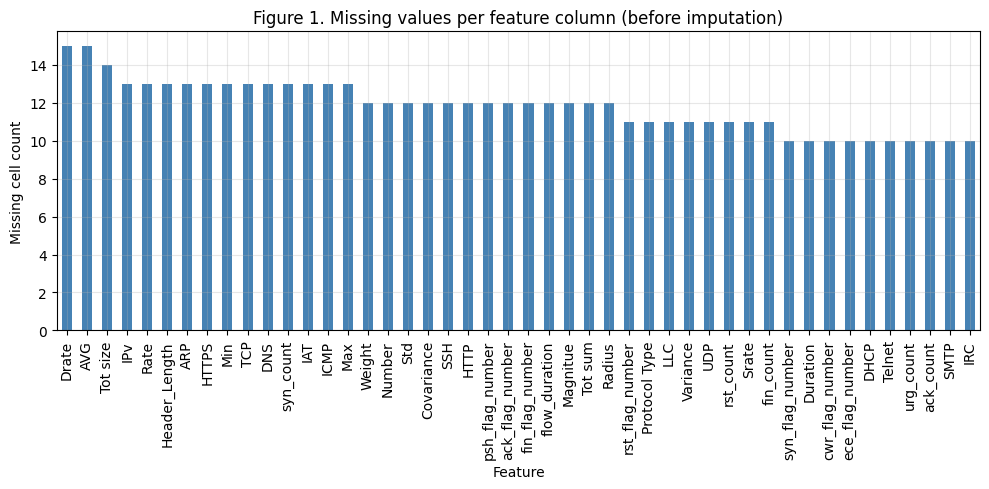

In [7]:
missing_before = df[feature_cols].isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)
print(f"Columns with missing values: {len(missing_before)} | Total missing cells: {missing_before.sum()}")

plt.figure(figsize=(10, 5))
missing_before.plot(kind='bar', color='steelblue')
plt.title("Figure 1. Missing values per feature column (before imputation)")
plt.ylabel("Missing cell count")
plt.xlabel("Feature")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("fig1_missing_values_alt.png", dpi=120)
plt.show()

In [8]:
median_imputer = SimpleImputer(strategy="median")
df[feature_cols] = median_imputer.fit_transform(df[feature_cols])

print("Total missing values remaining:", df[feature_cols].isnull().sum().sum())
assert df[feature_cols].isnull().sum().sum() == 0

Total missing values remaining: 0


## 7. Constant / Near-Zero-Variance Features with `sklearn.feature_selection.VarianceThreshold`

Instead of manually checking `std() == 0`, we use scikit-learn's `VarianceThreshold` selector,
which is the standard tool for this exact task and (again) is reusable directly inside a later
`Pipeline`. A small positive threshold (`1e-6`) is used instead of exactly `0` so that the
practically-constant column `Drate` (99.99% identical values, variance ≈ 8×10⁻⁹) is caught in the
same pass as the exactly-constant flag columns.

In [9]:
selector = VarianceThreshold(threshold=1e-6)
selector.fit(df[feature_cols])

kept_mask = selector.get_support()
dropped_variance_cols = [c for c, keep in zip(feature_cols, kept_mask) if not keep]
kept_variance_cols = [c for c, keep in zip(feature_cols, kept_mask) if keep]

print("Columns dropped by VarianceThreshold (constant / near-constant):")
print(dropped_variance_cols)

df = df.drop(columns=dropped_variance_cols)
feature_cols = kept_variance_cols
print(f"\nRemaining feature columns: {len(feature_cols)}")

Columns dropped by VarianceThreshold (constant / near-constant):
['Drate', 'ece_flag_number', 'cwr_flag_number', 'Telnet', 'SMTP', 'IRC', 'DHCP']

Remaining feature columns: 39


## 8. Redundant Features (Multicollinearity) via `numpy.corrcoef`

A correlation matrix is computed with `numpy.corrcoef` (vectorised, library-native, as an
alternative to `DataFrame.corr()`). Exact-duplicate pairs (**r > 0.999**) are safe to drop without
losing information; pairs between **0.95 and 0.999** are flagged for the Objective 2
feature-selection stage rather than removed here, since they may still carry partially distinct
signal useful for distinguishing attack types.

**Data-leakage check:** `label` is never included in `feature_cols`, so it cannot leak into the
inputs. No feature was found to be a disguised copy of the label. `Weight` (a near-constant
metadata-like field) is flagged for a feature-importance check in Objective 2.

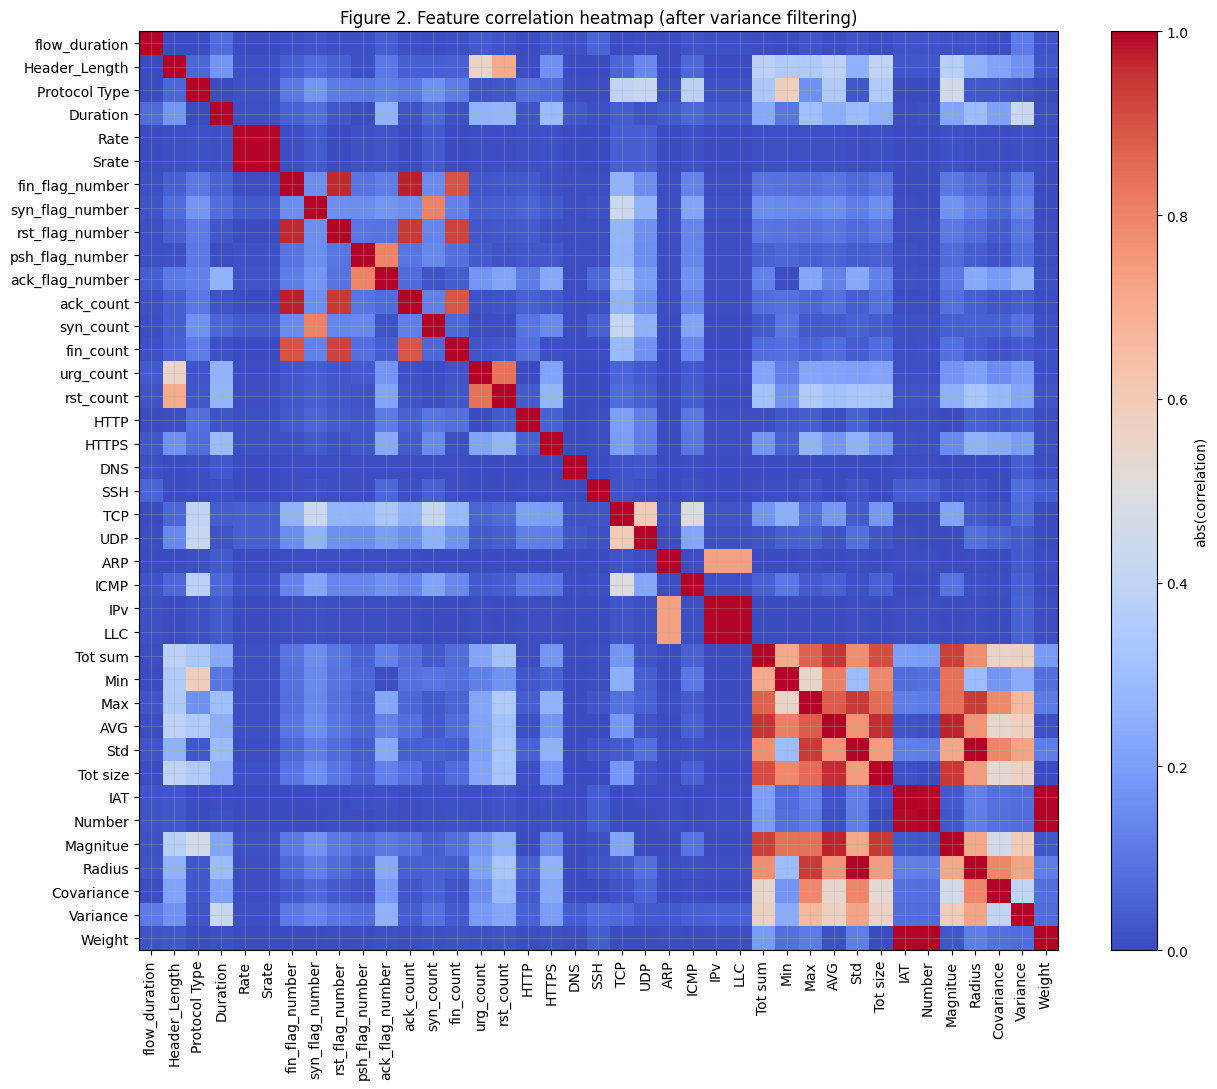

In [10]:
corr_matrix = np.corrcoef(df[feature_cols].values, rowvar=False)
corr_df = pd.DataFrame(np.abs(corr_matrix), index=feature_cols, columns=feature_cols)

fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(corr_df, cmap='coolwarm', vmin=0, vmax=1)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90)
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels(feature_cols)
fig.colorbar(im, ax=ax, label='abs(correlation)', fraction=0.046, pad=0.04)
ax.set_title("Figure 2. Feature correlation heatmap (after variance filtering)")
plt.tight_layout()
plt.savefig("fig2_correlation_heatmap_alt.png", dpi=120)
plt.show()

In [11]:
exact_dup_pairs, flagged_pairs = [], []
n = len(feature_cols)
for i in range(n):
    for j in range(i + 1, n):
        r = corr_df.iloc[i, j]
        if r > 0.999:
            exact_dup_pairs.append((feature_cols[i], feature_cols[j], round(float(r), 5)))
        elif 0.95 <= r <= 0.999:
            flagged_pairs.append((feature_cols[i], feature_cols[j], round(float(r), 4)))

print("Exact-duplicate feature pairs (r > 0.999):")
for p in exact_dup_pairs:
    print(" ", p)
print("\nStrongly correlated pairs flagged for Objective 2 feature selection (kept for now):")
for p in flagged_pairs:
    print(" ", p)

Exact-duplicate feature pairs (r > 0.999):
  ('Rate', 'Srate', 1.0)
  ('IPv', 'LLC', 1.0)
  ('Std', 'Radius', 0.99998)
  ('Number', 'Weight', 0.99958)

Strongly correlated pairs flagged for Objective 2 feature selection (kept for now):
  ('fin_flag_number', 'rst_flag_number', 0.968)
  ('fin_flag_number', 'ack_count', 0.9734)
  ('AVG', 'Tot size', 0.9575)
  ('AVG', 'Magnitue', 0.9708)
  ('IAT', 'Number', 0.995)
  ('IAT', 'Weight', 0.9961)


In [12]:
redundant_to_drop = {"Srate": "Rate", "LLC": "IPv", "Radius": "Std"}
dropped_redundant = [c for c in redundant_to_drop if c in df.columns]

df = df.drop(columns=dropped_redundant)
feature_cols = [c for c in feature_cols if c not in dropped_redundant]

print("Dropped redundant (exact-duplicate) features:", dropped_redundant)
print("Remaining feature columns:", len(feature_cols))

Dropped redundant (exact-duplicate) features: ['Srate', 'LLC', 'Radius']
Remaining feature columns: 36


## 9. Outlier Detection — Vectorised IQR with `numpy.percentile`

The same 1.5×IQR rule is used, but implemented as a single vectorised pass over the whole feature
matrix with `numpy.percentile` instead of a per-column pandas `.quantile()` loop. As in the first
notebook, outliers are **flagged for transparency and deliberately not removed**: in cyberattack
traffic, extreme values (very high packet rates, header lengths, byte totals) are very often the
actual attack signature, especially for the already-rare minority classes — deleting them would
remove exactly the evidence the classifier needs. Only the impossible sentinel values from
Section 4 were treated as genuine errors.

In [13]:
X = df[feature_cols].values
q1 = np.percentile(X, 25, axis=0)
q3 = np.percentile(X, 75, axis=0)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = (X < lower) | (X > upper)
outlier_counts = outlier_mask.sum(axis=0)
outlier_series = pd.Series(outlier_counts, index=feature_cols).sort_values(ascending=False)

top10 = outlier_series.head(10)
print("Top 10 columns by IQR outlier count (flagged, not removed):")
print(top10)

Top 10 columns by IQR outlier count (flagged, not removed):
AVG              15846
Tot sum          15824
Magnitue         15771
Tot size         15731
Min              14564
Duration         13857
Header_Length    11898
syn_count        11830
Covariance       10824
Rate             10717
dtype: int64


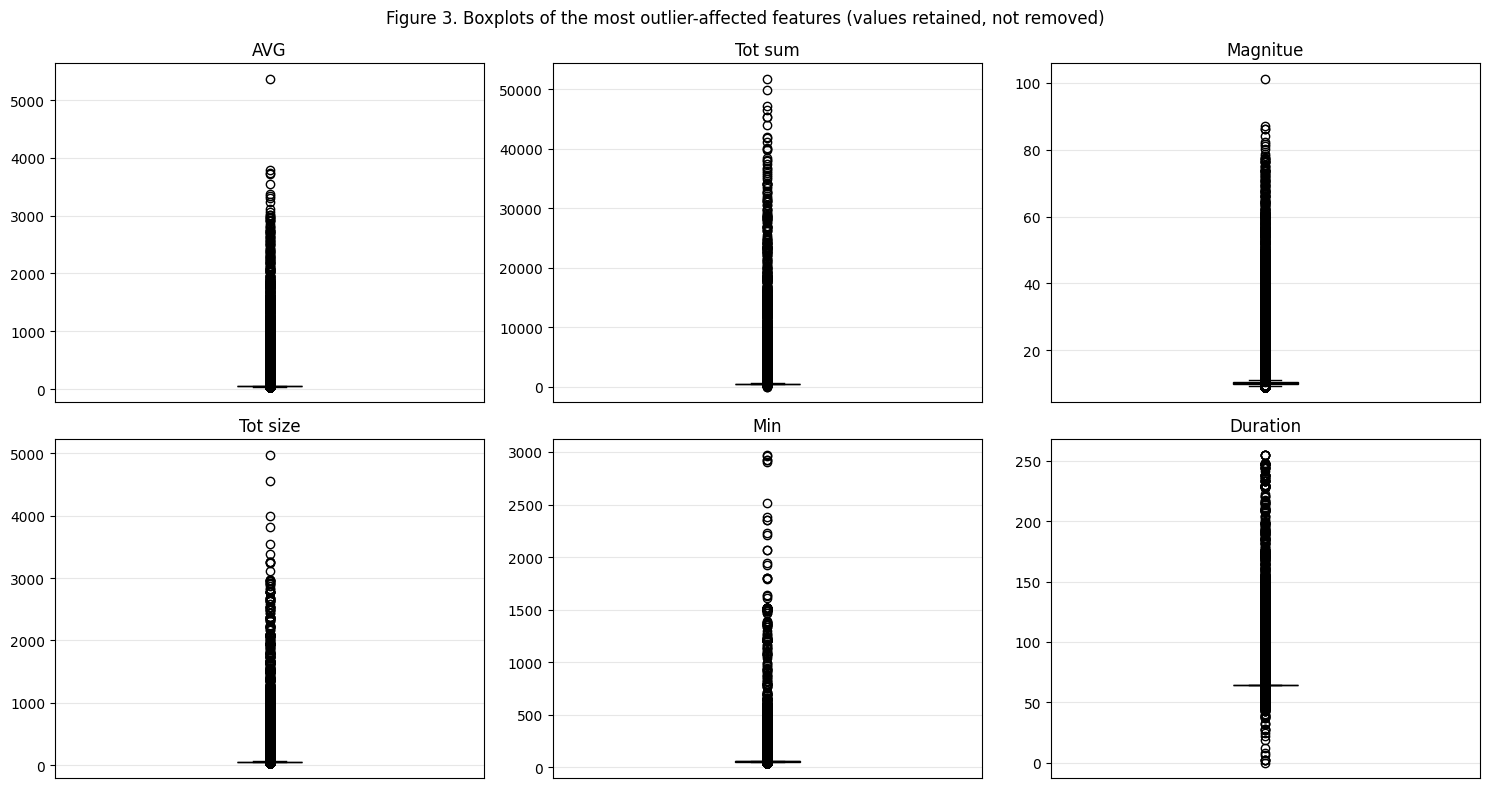

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), top10.index[:6]):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightcoral'), medianprops=dict(color='black'))
    ax.set_title(col)
    ax.set_xticks([])
plt.suptitle("Figure 3. Boxplots of the most outlier-affected features (values retained, not removed)")
plt.tight_layout()
plt.savefig("fig3_outlier_boxplots_alt.png", dpi=120)
plt.show()

## 10. Target Class Distribution and Imbalance

In [15]:
class_counts = df['label'].value_counts()
imbalance_ratio = class_counts.iloc[0] / class_counts.iloc[-1]
print(f"Number of classes: {df['label'].nunique()}")
print(f"Most frequent class: {class_counts.index[0]} ({class_counts.iloc[0]} records)")
print(f"Least frequent class: {class_counts.index[-1]} ({class_counts.iloc[-1]} records)")
print(f"Imbalance ratio (max:min): {imbalance_ratio:.1f} : 1")

Number of classes: 33
Most frequent class: DDoS-ICMP_Flood (7122 records)
Least frequent class: Uploading_Attack (33 records)
Imbalance ratio (max:min): 215.8 : 1


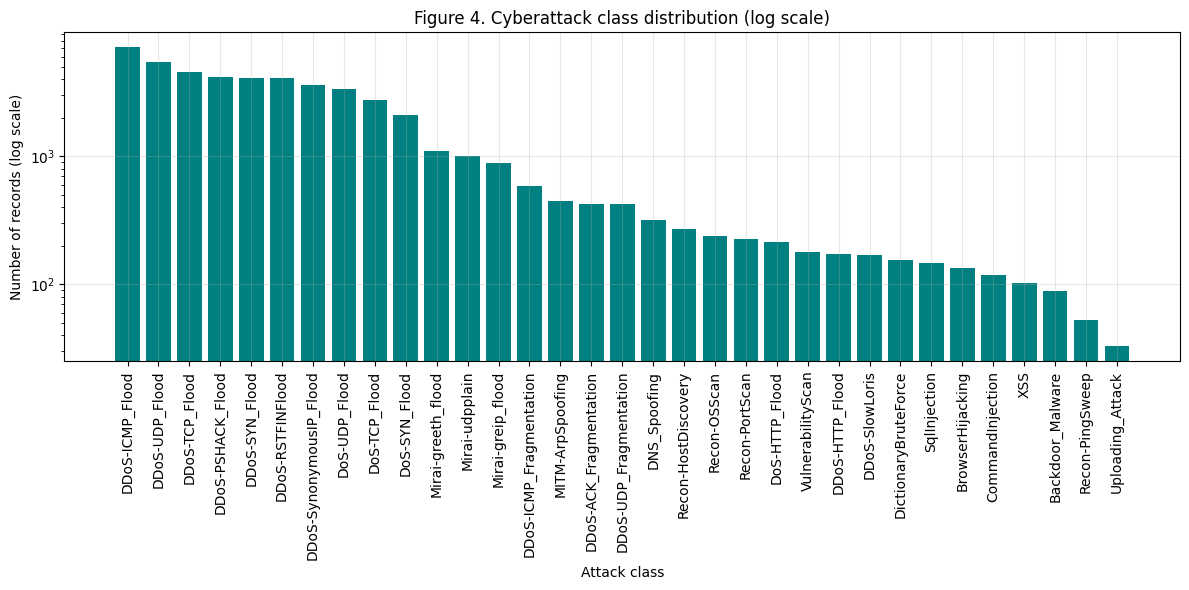

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(class_counts.index, class_counts.values, color='teal')
ax.set_yscale('log')
ax.set_title("Figure 4. Cyberattack class distribution (log scale)")
ax.set_ylabel("Number of records (log scale)")
ax.set_xlabel("Attack class")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("fig4_class_distribution_alt.png", dpi=120)
plt.show()

**Implication for later objectives:** the ~200:1 imbalance means Objective 3 must use a
**stratified train/test split**, evaluate with **macro-averaged precision/recall/F1** rather than
raw accuracy, and consider **class-weighting** (`class_weight='balanced'`) or **resampling**
(e.g. SMOTE) for rare classes such as `Uploading_Attack`, `Recon-PingSweep`, and
`Backdoor_Malware`. No resampling is applied at this cleaning stage — it must be fit on the
training split only, after the split, to avoid leaking information into the test set.

## 11. Feature Scaling — Demonstrated as a Single `sklearn.pipeline.Pipeline`

This alternate version demonstrates scaling as part of an actual scikit-learn `Pipeline`
(`SimpleImputer` → `StandardScaler`), fit **only on the training split** after a stratified
`train_test_split`. Wrapping the steps in a `Pipeline` guarantees the same fitted imputer/scaler
parameters are reused consistently on the test set without ever being fit on it — the correct way
to avoid data leakage, and the same pattern you will extend with a classifier step in Objective 3.

As before, this is for demonstration only: the **saved cleaned CSV is not scaled**, since scaling
parameters belong to a specific train/test split made at modelling time, not to a shared cleaned
dataset.

In [17]:
X_demo = df[feature_cols]
y_demo = df['label']

X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
    X_demo, y_demo, test_size=0.2, stratify=y_demo, random_state=42
)

scaling_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),   # no-op here (already clean) but kept for reuse in Obj. 3
    ("scale", StandardScaler()),
])

X_train_scaled_demo = scaling_pipeline.fit_transform(X_train_demo)   # fit ONLY on training data
X_test_scaled_demo = scaling_pipeline.transform(X_test_demo)         # test data only transformed

print("Demonstration only (not saved): stratified split sizes ->",
      X_train_demo.shape, X_test_demo.shape)
print("Pipeline fit on the training set only; test set transformed, not fit, to avoid leakage.")
print("This exact Pipeline object can be extended with a classifier step in Objective 3.")

Demonstration only (not saved): stratified split sizes -> (39028, 36) (9758, 36)
Pipeline fit on the training set only; test set transformed, not fit, to avoid leakage.
This exact Pipeline object can be extended with a classifier step in Objective 3.


## 12. Final Summary and Export of the Cleaned Dataset

In [18]:
print("="*70)
print("DATA CLEANING SUMMARY (Alternate / scikit-learn Pipeline Version)")
print("="*70)
print(f"Raw shape:     48826 rows x 47 columns (46 features + label)")
print(f"Cleaned shape: {df.shape[0]} rows x {df.shape[1]} columns "
      f"({df.shape[1]-1} features + label)")
print(f"\nRows removed (exact duplicates): {n_dupes}")
print(f"Feature columns removed: {len(dropped_variance_cols) + len(dropped_redundant)}")
print(f"  - Zero/near-zero variance (VarianceThreshold): {dropped_variance_cols}")
print(f"  - Redundant (r>0.999) duplicates: {dropped_redundant}")
print(f"Missing cells imputed with median (SimpleImputer): {int(missing_before.sum())}")
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")
print(f"Remaining duplicate rows: {df.duplicated().sum()}")
print(f"Class imbalance ratio: {imbalance_ratio:.1f} : 1 (documented for Objective 3)")
print(f"Strongly correlated pairs flagged for Objective 2: {len(flagged_pairs)}")
print("="*70)

df.to_csv("Dataset_Brief_2_cleaned_alt.csv", index=False)
print("\nCleaned dataset saved to 'Dataset_Brief_2_cleaned_alt.csv'")

DATA CLEANING SUMMARY (Alternate / scikit-learn Pipeline Version)
Raw shape:     48826 rows x 47 columns (46 features + label)
Cleaned shape: 48786 rows x 37 columns (36 features + label)

Rows removed (exact duplicates): 40
Feature columns removed: 10
  - Zero/near-zero variance (VarianceThreshold): ['Drate', 'ece_flag_number', 'cwr_flag_number', 'Telnet', 'SMTP', 'IRC', 'DHCP']
  - Redundant (r>0.999) duplicates: ['Srate', 'LLC', 'Radius']
Missing cells imputed with median (SimpleImputer): 544

Remaining missing values: 0
Remaining duplicate rows: 0
Class imbalance ratio: 215.8 : 1 (documented for Objective 3)
Strongly correlated pairs flagged for Objective 2: 6



Cleaned dataset saved to 'Dataset_Brief_2_cleaned_alt.csv'


## 13. Conclusion

This alternate notebook reaches the **same cleaned dataset and the same conclusions** as the
original (formatting/sentinel fixes, median imputation, duplicate removal, constant/redundant
feature removal, outliers retained and reported, class imbalance quantified, scaling deferred to
after the train/test split) but implements each step with scikit-learn's reusable building blocks
(`VarianceThreshold`, `SimpleImputer`, `Pipeline`) instead of manual pandas operations. This style
is directly reusable when you assemble the Objective 3 modelling pipeline, since the same
`SimpleImputer`/`StandardScaler` steps shown here can simply have a classifier appended to them.
The dataset produced here (`Dataset_Brief_2_cleaned_alt.csv`) is ready for Objective 2
(Feature Analysis and Selection).